# Step 6 (optional): Resolution test

Does the melt rate change if I halve the horizontal grid spacing? The sloping ice base is a staircase of grid cells (step 2), and finer cells make a finer staircase and resolve the narrow meltwater plume better. I repeat the step 3 case with the far field at -0.9 °C (`open_p10`) on a grid with half the spacing in both directions (0.15° x 0.05°, so 100 x 200 points instead of 50 x 100), and compare the first 2 model years with the coarse run.

Everything else is the same: 30 levels of 30 m, the 1800 s time step, the open-ocean restoring zone, the three-equation melt model with constant transfer coefficients, and the cold start. I kept the time step because the horizontal viscosity is still stable on the finer grid: the stability number Ah x dt x (1/dx^2 + 1/dy^2) is about 0.16, below the limit of 0.25 for explicit Laplacian friction.

I load the libraries and set the paths and grid sizes.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")   # isomip_tools.py lives in the project's src/ folder
from isomip_tools import read_grid, output_iterations, read_field, melt_rate, area_mean, melt_series, RHO_ICE

RUNS = os.path.expanduser("~/mitgcm_runs/isomip")
INPUT = os.path.join(RUNS, "source_copy", "input")
FINE_DIR = os.path.join(RUNS, "inputs_fine")          # fine-grid input files, outside the repo
NX_C, NY_C = 50, 100                                  # original grid
NX_F, NY_F, NR = 100, 200, 30                         # fine grid (SIZE.h in experiments/fine_code)
DLON_F, DLAT_F = 0.15, 0.05                           # fine grid spacing (degrees)
T_FAR = -0.9                                          # far-field temperature of the compared case (°C)
S_FAR = 34.4
ZONE_SOUTH, ZONE_NORTH = -71.0, -70.0                 # ice front and northern wall
COMPARE_YEARS = 2                                     # length of the fine run (years)
AH, DT = 600.0, 1800.0                                # horizontal viscosity (m^2/s) and time step (s)
FIG_DIR = "../figures"
os.makedirs(FINE_DIR, exist_ok=True)

A quick check of the viscosity stability number on the finest cells of the new grid (near 80°S).

In [2]:
radius = 6.371e6
dx_min = radius * np.cos(np.deg2rad(-80.0 + DLAT_F / 2)) * np.deg2rad(DLON_F)
dy = radius * np.deg2rad(DLAT_F)
print(f"smallest cells: dx {dx_min / 1e3:.2f} km, dy {dy / 1e3:.2f} km | Ah dt (1/dx^2 + 1/dy^2) = {AH * DT * (1 / dx_min ** 2 + 1 / dy ** 2):.3f} (limit 0.25)")

smallest cells: dx 2.90 km, dy 5.56 km | Ah dt (1/dx^2 + 1/dy^2) = 0.163 (limit 0.25)


## Part A: fine-grid input files

The original ice draft follows a simple rule: it rises 125 m per degree of latitude from -700 m at 80°S and stops at -200 m. (My first version used np.maximum instead of np.minimum and this check caught it: drafts are negative, so the cap needs the minimum.) I check that this rule gives back the original file exactly before using it on the fine grid.

In [3]:
def ice_draft_rule(lat):
    return np.minimum(-700.0 + (lat + 80.0) * 125.0, -200.0)   # drafts are negative: the slope is capped at -200 m

lat_c = -80.0 + 0.1 * (np.arange(NY_C) + 0.5)
ice_c = np.fromfile(os.path.join(INPUT, "icetopo.exp1"), dtype=">f8").reshape(NY_C, NX_C)
print(f"largest difference between the rule and the original file: {np.max(np.abs(ice_draft_rule(lat_c) - ice_c[:, 1])):.2e} m")

largest difference between the rule and the original file: 1.82e-12 m


The ice load depends only on the draft (step 3). I interpolate it from the original draft-to-load table, and check that the interpolation gives back the original values exactly at the original drafts.

In [4]:
load_c = np.fromfile(os.path.join(INPUT, "phi0surf.exp1.jmd95z"), dtype=">f8").reshape(NY_C, NX_C)
bathy_c = np.fromfile(os.path.join(INPUT, "bathy.box"), dtype=">f8").reshape(NY_C, NX_C)
drafts = []
loads = []
for j in range(1, NY_C):                      # row 0 is the wall
    if ice_c[j, 1] not in drafts:
        drafts.append(ice_c[j, 1])
        loads.append(load_c[j, 1])
order = np.argsort(drafts)
drafts = np.array(drafts)[order]
loads = np.array(loads)[order]
print(f"table: {len(drafts)} drafts from {drafts.min()} to {drafts.max()} m | largest error at the table points: "
      f"{np.max(np.abs(np.interp(drafts, drafts, loads) - loads)):.2e}")

table: 40 drafts from -681.250000000001 to -200.0 m | largest error at the table points: 0.00e+00


Now the fine-grid fields: walls in the first row and column (as in the original), a 900 m flat seafloor, the ice draft from the rule with the ice removed north of 71°S, the interpolated load, the restoring mask (0 at the ice front rising to the northern wall, all depths, only in the open zone), and the uniform targets. All are 64-bit, big-endian.

In [5]:
lat_f = -80.0 + DLAT_F * (np.arange(NY_F) + 0.5)
bathy_f = np.full((NY_F, NX_F), -900.0)
bathy_f[0, :] = 0.0
bathy_f[:, 0] = 0.0
ice_f = np.zeros((NY_F, NX_F))
load_f = np.zeros((NY_F, NX_F))
mask_f = np.zeros((NR, NY_F, NX_F))
for j in range(NY_F):
    if lat_f[j] > ZONE_SOUTH:
        mask_f[:, j, 1:] = (lat_f[j] - ZONE_SOUTH) / (ZONE_NORTH - ZONE_SOUTH)   # open ocean, no ice
    else:
        ice_f[j, :] = ice_draft_rule(lat_f[j])
        d = ice_f[j, 1]
        if d < drafts[0]:
            # deeper than every table entry (the deepest fine row): extend the table in a straight line
            slope = (loads[1] - loads[0]) / (drafts[1] - drafts[0])
            load_f[j, 1:] = loads[0] + (d - drafts[0]) * slope
        else:
            load_f[j, 1:] = np.interp(d, drafts, loads)
mask_f[:, 0, :] = 0.0                                 # no restoring in the wall row
files = {"bathy_fine.bin": bathy_f, "icetopo_fine.bin": ice_f, "phi0surf_fine.bin": load_f,
         "rbcs_mask_fine.bin": mask_f, "salt_fine.bin": np.full((NR, NY_F, NX_F), S_FAR),
         "theta_fine_p10.bin": np.full((NR, NY_F, NX_F), T_FAR)}
for name, field in files.items():
    field.astype(">f8").tofile(os.path.join(FINE_DIR, name))
    print(f"wrote {name}: {os.path.getsize(os.path.join(FINE_DIR, name))} bytes")
print(f"deepest fine draft {ice_f[1, 1]:.3f} m -> load {load_f[1, 1]:.2f} (table ends at {drafts[0]:.2f} m, load {loads[0]:.2f})")
print(f"fine grid: ice front between rows {np.where(lat_f < ZONE_SOUTH)[0][-1]} and {np.where(lat_f > ZONE_SOUTH)[0][0]}, "
      f"ice-covered ocean columns {np.sum((ice_f < 0) & (bathy_f < 0))}")

wrote bathy_fine.bin: 160000 bytes
wrote icetopo_fine.bin: 160000 bytes
wrote phi0surf_fine.bin: 160000 bytes
wrote rbcs_mask_fine.bin: 4800000 bytes
wrote salt_fine.bin: 4800000 bytes
wrote theta_fine_p10.bin: 4800000 bytes
deepest fine draft -690.625 m -> load -4261.63 (table ends at -681.25 m, load -4350.13)
fine grid: ice front between rows 179 and 180, ice-covered ocean columns 17721


## Part B: comparison

I read both grids and compare the area-mean melt under the ice over the first 2 years, month by month.

In [6]:
coarse = os.path.join(RUNS, "open_p10")
fine = os.path.join(RUNS, "fine_p10")
def nan_in_log(text):
    # NaN in the model's own output lines; lines starting with "(PID.TID 0000.0001) >" echo the input files
    for line in text.splitlines():
        if "NaN" in line and not line.startswith("(PID.TID 0000.0001) >"):
            return True
    return False

text = open(os.path.join(fine, "output.txt")).read()
print("fine run ended normally:", "Execution ended Normally" in text, "| NaN in log:", nan_in_log(text))
g_c = read_grid(coarse, "../experiments/open_geometry", ice_file="icetopo_open_north.bin")
g_f = read_grid(fine, FINE_DIR, ice_file="icetopo_fine.bin")
print(f"ice-covered columns: coarse {g_c['iced'].sum()}, fine {g_f['iced'].sum()} | "
      f"ice-covered area: coarse {np.sum(g_c['rac'] * g_c['iced']):.4e} m^2, fine {np.sum(g_f['rac'] * g_f['iced']):.4e} m^2")
days_f, melt_f = melt_series([fine], g_f, g_f["iced"])
days_c, melt_c = melt_series([coarse], g_c, g_c["iced"])
n = len(melt_f)
print(f"fine run: {n} monthly means over {days_f[-1] / 365:.2f} years")
with open("../data/resolution_test.csv", "w") as f:
    f.write("year,coarse_melt_m_per_yr,fine_melt_m_per_yr,fine_over_coarse\n")
    for year in range(1, COMPARE_YEARS + 1):
        sl = slice(12 * (year - 1), 12 * year)
        print(f"year {year}: coarse {melt_c[sl].mean():.4f} m/yr, fine {melt_f[sl].mean():.4f} m/yr, "
              f"fine/coarse {melt_f[sl].mean() / melt_c[sl].mean():.3f}")
        f.write(f"{year},{melt_c[sl].mean():.5f},{melt_f[sl].mean():.5f},{melt_f[sl].mean() / melt_c[sl].mean():.4f}\n")
print("saved ../data/resolution_test.csv")

fine run ended normally: True | NaN in log: False


ice-covered columns: coarse 4361, fine 17721 | ice-covered area: coarse 4.0585e+11 m^2, fine 4.1160e+11 m^2


fine run: 24 monthly means over 1.97 years
year 1: coarse 0.3472 m/yr, fine 0.3684 m/yr, fine/coarse 1.061
year 2: coarse 0.2388 m/yr, fine 0.2594 m/yr, fine/coarse 1.086
saved ../data/resolution_test.csv


The melt rate over time on both grids, with the rest of the coarse 10-year run for context.

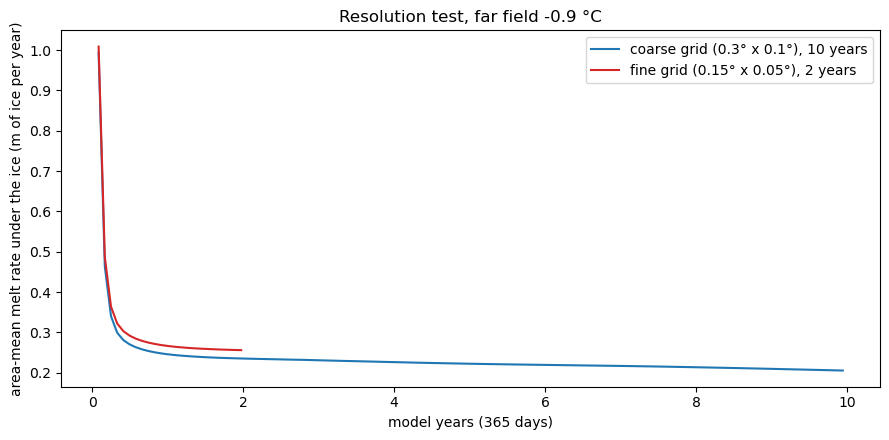

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(days_c / 365, melt_c, color="tab:blue", label="coarse grid (0.3° x 0.1°), 10 years")
ax.plot(days_f / 365, melt_f, color="tab:red", label="fine grid (0.15° x 0.05°), 2 years")
ax.set_xlabel("model years (365 days)")
ax.set_ylabel("area-mean melt rate under the ice (m of ice per year)")
ax.set_title("Resolution test, far field -0.9 °C")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_resolution_melt.png"), dpi=150)
plt.show()

Melt maps of the last fine-grid year on both grids, on the same colour scale, and the zonal-mean melt against latitude.

coarse: largest melt 6.444 m/yr, strongest refreezing -0.467 m/yr
fine: largest melt 8.809 m/yr, strongest refreezing -0.508 m/yr


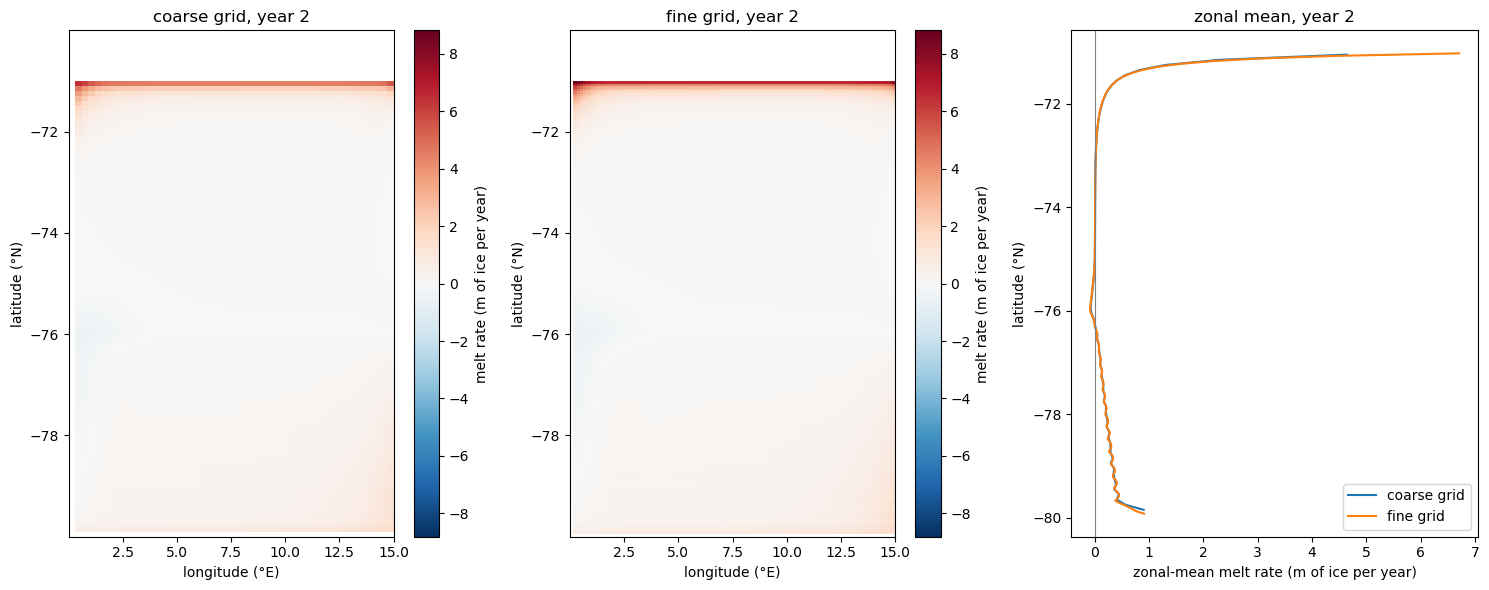

In [8]:
def year_mean_map(run, grid, year):
    its = output_iterations(run, "shelfice_monthly")[12 * (year - 1):12 * year]
    m = np.zeros(grid["iced"].shape)
    for it in its:
        m += melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
    return np.where(grid["iced"], m, np.nan)

maps = {"coarse": (year_mean_map(coarse, g_c, COMPARE_YEARS), g_c), "fine": (year_mean_map(fine, g_f, COMPARE_YEARS), g_f)}
lim = max(np.nanmax(np.abs(maps["coarse"][0])), np.nanmax(np.abs(maps["fine"][0])))
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, label in zip(axes[:2], ["coarse", "fine"]):
    m, g = maps[label]
    lon = g["xc"][0, :]
    lat = g["yc"][:, 0]
    mesh = ax.pcolormesh(lon, lat, m, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
    ax.set_xlabel("longitude (°E)")
    ax.set_ylabel("latitude (°N)")
    ax.set_title(f"{label} grid, year {COMPARE_YEARS}")
    fig.colorbar(mesh, ax=ax, label="melt rate (m of ice per year)")
    rows = np.any(np.isfinite(m), axis=1)            # rows with ice (the open-ocean rows have no melt values)
    zonal = np.full(len(lat), np.nan)
    for j in np.where(rows)[0]:
        zonal[j] = np.nanmean(m[j])
    axes[2].plot(zonal, lat, label=f"{label} grid")
    print(f"{label}: largest melt {np.nanmax(m):.3f} m/yr, strongest refreezing {np.nanmin(m):.3f} m/yr")
axes[2].axvline(0, color="0.5", lw=0.8)
axes[2].set_xlabel("zonal-mean melt rate (m of ice per year)")
axes[2].set_ylabel("latitude (°N)")
axes[2].set_title(f"zonal mean, year {COMPARE_YEARS}")
axes[2].legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_resolution_maps.png"), dpi=150)
plt.show()

Where does the difference come from? I split the ice into the strip within 0.1° of the ice front (one coarse row, two fine rows), the rest of the ice, and the deep ice (draft deeper than 300 m), for the last fine-grid year.

In [9]:
for label, g, run in [("coarse", g_c, coarse), ("fine", g_f, fine)]:
    its = output_iterations(run, "shelfice_monthly")[12 * (COMPARE_YEARS - 1):12 * COMPARE_YEARS]
    m = np.zeros(g["iced"].shape)
    for it in its:
        m += melt_rate(read_field(run, "shelfice_monthly", "SHIfwFlx", it)) / len(its)
    ice = g["iced"]
    strip = ice & (g["yc"] > ZONE_SOUTH - 0.1)
    deep = ice & (g["ice_draft"] < -300.0)
    total = np.sum(m * g["rac"] * ice)
    print(f"{label:6s}: total melt {total * RHO_ICE / 1e12:.2f} Gt of ice per year | strip at the ice front {area_mean(m, g, strip):.3f} m/yr "
          f"({100 * np.sum(m * g['rac'] * strip) / total:.1f}% of the total) | rest of the ice {area_mean(m, g, ice & ~strip):.4f} m/yr | "
          f"deep ice {area_mean(m, g, deep):.4f} m/yr")

coarse: total melt 88.88 Gt of ice per year | strip at the ice front 4.637 m/yr (28.2% of the total) | rest of the ice 0.1739 m/yr | deep ice 0.2666 m/yr
fine  : total melt 97.91 Gt of ice per year | strip at the ice front 5.549 m/yr (31.0% of the total) | rest of the ice 0.1817 m/yr | deep ice 0.2708 m/yr
